In [1]:
!pip install datasets transformers

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 491.2/491.2 kB 10.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 116.3/116.3 kB 11.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 183.9/183.9 kB 17.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 143.5/143.5 kB 16.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 194.8/194.8 kB 19.5 MB/s eta 0:00:00
  Attempting uninstall: fsspec
    Found existing installation: fsspec 2025.3.2
    Uninstalling fsspec-2025.3.2:
      Successfully uninstalled fsspec-2025.3.2
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
gcsfs 2025.3.2 requires fsspec==2025.3.2, but you have fsspec 2024.12.0 which is incompatible.
torch 2.6.0+cu124 requires nvidia-cublas-cu12==12.4.5.8; platform_system == "Linux" and platform_machine == "x86_64", but you have nvidia-cublas-cu12 12.5.3.2 which

In [2]:
import pandas as pd
import torch
import numpy as np
import re
import time
import random
import datetime
import matplotlib.pyplot as plt
from bs4 import BeautifulSoup
from torch import nn
from torch.optim import AdamW
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, classification_report
from tqdm import tqdm
from datasets import Dataset, DatasetDict
from google.colab import drive
from torch.utils.data import Dataset, DataLoader, random_split, RandomSampler, SequentialSampler
from transformers import GPT2Tokenizer, GPT2LMHeadModel, GPT2Config, get_linear_schedule_with_warmup, StoppingCriteria, StoppingCriteriaList

In [3]:
drive.mount('/content/drive')

Mounted at /content/drive


0    Job Ad: (Job title: CEO\nAbstract: Exciting op...
1    Job Ad: (Job title: Home-Based Online ESL Teac...
2    Job Ad: (Job title: Safeguarding, De La Salle\...
3    Job Ad: (Job title: Delivery Driver\nAbstract:...
4    Job Ad: (Job title: Store Supervisor\nAbstract...
Name: input_text, dtype: object


<ipython-input-4-48faf4516def>:18: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  .apply(lambda grp: grp.sample(n=min_count, random_state=42))      # for reproducibility


<Axes: xlabel='y_true'>

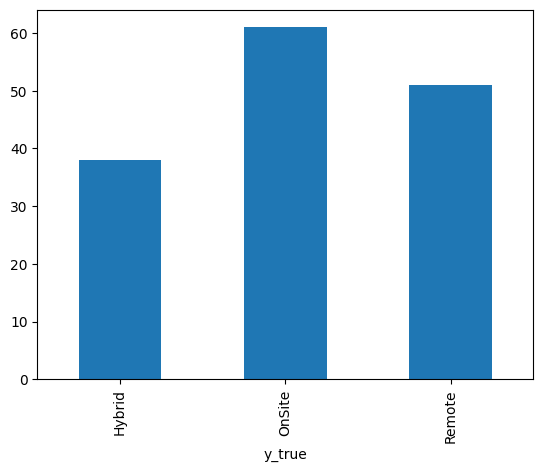

In [4]:
# Load test data
df_train = pd.read_csv('/content/drive/My Drive/Colab Notebooks/job_data_files/work_arrangements_development_set.csv')
df_test = pd.read_csv('/content/drive/My Drive/Colab Notebooks/job_data_files/work_arrangements_test_set.csv')

# Load the Claude and GPT4.1-labeled data
df_combined = pd.read_csv('/content/drive/My Drive/Colab Notebooks/job_data_files/combined_work_arrangements_unlabelled_set.csv')

df_combined = df_combined[df_combined['y_true'].isin(['OnSite', 'Hybrid', 'Remote'])]

# Compute the count of each class
counts = df_combined['y_true'].value_counts()
min_count = counts.min()

# Undersample each class to 'min_count' rows
balanced_parts = (
    df_combined
    .groupby('y_true', group_keys=False)                # split by class
    .apply(lambda grp: grp.sample(n=min_count, random_state=42))      # for reproducibility
)

# Shuffle the balanced DataFrame
df_combined = balanced_parts.sample(frac=1, random_state=42).reset_index(drop=True)

# Concatenate the two DataFrames
df_train = pd.concat([df_train, df_combined], ignore_index=True)

# Define a helper function to remove HTML tags from text.
def cleanText(text):
    if pd.isnull(text):
        return ""
    soup = BeautifulSoup(text, "html.parser")
    cleaned_text = soup.get_text(separator=" ", strip=True)

    # This pattern matches anything that is not a letter, digit, space, or specified punctuation
    pattern = r'[^a-zA-Z0-9\s!?,.:();&$€£¥₹/\|-]'
    # Use re.sub() to replace unwanted characters with an empty string
    cleaned_text = re.sub(pattern, '', cleaned_text)
    return cleaned_text

# Clean job_ad_details and create a new column
df_train['job_ad_clean'] = df_train['job_ad'].apply(cleanText)
df_test['job_ad_clean'] = df_test['job_ad'].apply(cleanText)

df_train['input_text'] = (
    "Job Ad: (" + df_train['job_ad_clean'].fillna('') + ") " +
    "Work Arrangements: (" + df_train['y_true'] + ")"
)


df_test['input_text'] = (
    "Job Ad: (" + df_test['job_ad_clean'].fillna('') + ") " +
    "Work Arrangements: ("
)

# Show a preview of the cleaned data
print(df_train['input_text'].head())
df_train.groupby("y_true").size().plot.bar()

In [5]:
# Load the GPT tokenizer.
tokenizer = GPT2Tokenizer.from_pretrained("openai-community/gpt2-medium", bos_token='<|startoftext|>', eos_token='<|endoftext|>', pad_token='<|pad|>')

tokenizer.padding_side = 'right'  # Ensure padding is on the right
tokenizer.truncation_side = 'left'  # Truncate from the left

/usr/local/lib/python3.11/dist-packages/huggingface_hub/utils/_auth.py:94: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


tokenizer_config.json:   0%|          | 0.00/26.0 [00:00<?, ?B/s]

vocab.json:   0%|          | 0.00/1.04M [00:00<?, ?B/s]

merges.txt:   0%|          | 0.00/456k [00:00<?, ?B/s]

tokenizer.json:   0%|          | 0.00/1.36M [00:00<?, ?B/s]

config.json:   0%|          | 0.00/718 [00:00<?, ?B/s]

In [6]:
batch_size = 8

In [7]:
class GPT2Dataset(Dataset):

  def __init__(self, txt_list, tokenizer, max_length=1024):

    self.tokenizer = tokenizer
    self.input_ids = []
    self.attn_masks = []

    for txt in txt_list:

      encodings_dict = tokenizer('<|startoftext|>'+ txt + '<|endoftext|>', truncation=True, max_length=max_length, padding="max_length")

      self.input_ids.append(torch.tensor(encodings_dict['input_ids']))
      self.attn_masks.append(torch.tensor(encodings_dict['attention_mask']))

  def __len__(self):
    return len(self.input_ids)

  def __getitem__(self, idx):
    return self.input_ids[idx], self.attn_masks[idx]

In [8]:
train_dataset = GPT2Dataset(df_train['input_text'], tokenizer)

def process_data(df):
    tokenized_input = tokenizer.encode(df['input_text'], return_tensors="pt")
    # Slice from the beginning to keep only the last 1000 tokens
    return tokenized_input[:, -1000:]

df_test['input_ids'] = df_test.apply(process_data, axis=1)

print('{:>5,} training samples'.format(len(train_dataset)))

print('{:>5,} testing samples'.format(len(df_test)))

Token indices sequence length is longer than the specified maximum sequence length for this model (1114 > 1024). Running this sequence through the model will result in indexing errors


  150 training samples
   99 testing samples


In [9]:
# Create the DataLoaders for our training and validation datasets.
# We'll take training samples in random order.
train_dataloader = DataLoader(
    train_dataset,               # The training dataset
    sampler=RandomSampler(train_dataset),  # Select batches randomly
    batch_size=batch_size,       # Training batch size
    pin_memory=True              # Enable pinned memory
)

In [10]:
# I'm not really doing anything with the config buheret
configuration = GPT2Config.from_pretrained('openai-community/gpt2-medium', output_hidden_states=False)

# instantiate the model
model = GPT2LMHeadModel.from_pretrained("openai-community/gpt2-medium", config=configuration)

# this step is necessary because I've added some tokens (bos_token, etc) to the embeddings
# otherwise the tokenizer and model tensors won't match up
model.resize_token_embeddings(len(tokenizer))

# Tell pytorch to run this model on the GPU.
device = torch.device("cuda")
model.cuda()

# Set the seed value all over the place to make this reproducible.
seed_val = 42

random.seed(seed_val)
np.random.seed(seed_val)
torch.manual_seed(seed_val)
torch.cuda.manual_seed_all(seed_val)

Xet Storage is enabled for this repo, but the 'hf_xet' package is not installed. Falling back to regular HTTP download. For better performance, install the package with: `pip install huggingface_hub[hf_xet]` or `pip install hf_xet`


model.safetensors:   0%|          | 0.00/1.52G [00:00<?, ?B/s]

generation_config.json:   0%|          | 0.00/124 [00:00<?, ?B/s]

The new embeddings will be initialized from a multivariate normal distribution that has old embeddings' mean and covariance. As described in this article: https://nlp.stanford.edu/~johnhew/vocab-expansion.html. To disable this, use `mean_resizing=False`


In [11]:
# Define a custom stopping criterion that stops generation when a specific token is produced.
class StopOnToken(StoppingCriteria):
    def __init__(self, token_id):
        self.token_id = token_id

    def __call__(self, input_ids: torch.LongTensor, scores: torch.FloatTensor, **kwargs) -> bool:
        # Check if the last token in the sequence is the stop token.
        # input_ids shape: [batch_size, sequence_length]
        if input_ids[0, -1] == self.token_id:
            return True
        return False

# Get the token id for the closing parenthesis: ')'
stop_token_id = tokenizer.encode(")")[0]

# Create a stopping criteria list with our custom criterion
stopping_criteria = StoppingCriteriaList([StopOnToken(stop_token_id)])

In [12]:
# some parameters I cooked up that work reasonably well
epochs = 20
learning_rate = 0.0002
warmup_steps = 1e2
epsilon = 1e-8

# this produces sample output every 100 steps
sample_every = 100

In [13]:
# Note: AdamW is a class from the huggingface library (as opposed to pytorch)
optimizer = AdamW(model.parameters(),
          lr = learning_rate,
          eps = epsilon
          )

In [14]:
# Total number of training steps is [number of batches] x [number of epochs].
# (Note that this is not the same as the number of training samples).
total_steps = len(train_dataloader) * epochs

# Create the learning rate scheduler.
# This changes the learning rate as the training loop progresses
scheduler = get_linear_schedule_with_warmup(optimizer,
                       num_warmup_steps = warmup_steps,
                       num_training_steps = total_steps)

In [15]:
def format_time(elapsed):
    return str(datetime.timedelta(seconds=int(round((elapsed)))))

In [16]:
total_t0 = time.time()
training_stats = []
model = model.to(device)

for epoch_i in range(0, epochs):

    # ========================================
    #               Training
    # ========================================

    print("")
    print('======== Epoch {:} / {:} ========'.format(epoch_i + 1, epochs))
    print('Training...')

    t0 = time.time()
    total_train_loss = 0
    model.train()

    for step, batch in enumerate(tqdm(train_dataloader)):

        b_input_ids = batch[0].to(device, non_blocking=True)
        b_labels = batch[0].to(device, non_blocking=True)
        b_masks = batch[1].to(device, non_blocking=True)

        model.zero_grad()

        outputs = model(b_input_ids,
                 labels=b_labels,
                 attention_mask = b_masks,
                 token_type_ids=None
                 )

        loss = outputs[0]

        batch_loss = loss.item()
        total_train_loss += batch_loss

        loss.backward()
        optimizer.step()
        scheduler.step()

    # Calculate the average loss over all of the batches.
    avg_train_loss = total_train_loss / len(train_dataloader)

    # Measure how long this epoch took.
    training_time = format_time(time.time() - t0)

    print("")
    print("  Average training loss: {0:.2f}".format(avg_train_loss))
    print("  Training epoch took: {:}".format(training_time))

    # ========================================
    #               Validation
    # ========================================

    print("")
    print("Running Validation...")

    t0 = time.time()

    model.eval()

    total_eval_acc = 0
    nb_eval_steps = 0

    # Evaluate data for one epoch
    model.eval()

    for tokenized_input, true_output in zip(df_test['input_ids'], df_test['y_true']):

        tokenized_input = tokenized_input.to(device)
        attention_mask = torch.ones(tokenized_input.shape, device=device)

        outputs = model.generate(input_ids=tokenized_input,
                      attention_mask=attention_mask,
                      pad_token_id=tokenizer.pad_token_id,
                      do_sample=True,
                      top_k=20,
                      max_new_tokens=5,
                      top_p=0.95,
                      num_return_sequences=1,
                      stopping_criteria=stopping_criteria)
        generated_tokens = outputs[0, tokenized_input.size(1)-1:]

        generated_text = tokenizer.decode(generated_tokens, skip_special_tokens=True)

        # Use a regular expression to capture the text between the first "(" and the first ")".
        match = re.search(r'\((.*?)\)', generated_text)
        if match:
            # This will capture the text inside the parentheses.
            extracted_text = match.group(1)
        else:
            extracted_text = generated_text[2:]  # Fallback in case no matching pattern is found

        if extracted_text == true_output:
            total_eval_acc += 1

    avg_val_acc = total_eval_acc / len(df_test)

    model.train()

    validation_time = format_time(time.time() - t0)

    print("  Validation Acc: {0:.3f}".format(avg_val_acc))
    print("  Validation took: {:}".format(validation_time))

    # Record all statistics from this epoch.
    training_stats.append(
        {
            'epoch': epoch_i + 1,
            'Training Loss': avg_train_loss,
            'Valid. Acc': avg_val_acc,
            'Training Time': training_time,
            'Validation Time': validation_time
        }
    )

print("")
print("Training complete!")
print("Total training took {:} (h:mm:ss)".format(format_time(time.time()-total_t0)))


======== Epoch 1 / 20 ========
Training...


100%|██████████| 19/19 [00:25<00:00,  1.32s/it]



  Average training loss: 8.95
  Training epoch took: 0:00:25

Running Validation...
  Validation Acc: 0.000
  Validation took: 0:00:11

======== Epoch 2 / 20 ========
Training...


100%|██████████| 19/19 [00:24<00:00,  1.27s/it]



  Average training loss: 7.45
  Training epoch took: 0:00:24

Running Validation...
  Validation Acc: 0.071
  Validation took: 0:00:09

======== Epoch 3 / 20 ========
Training...


...


  Average training loss: 0.07
  Training epoch took: 0:00:24

Running Validation...
  Validation Acc: 0.778
  Validation took: 0:00:07

======== Epoch 19 / 20 ========
Training...


100%|██████████| 19/19 [00:24<00:00,  1.26s/it]



  Average training loss: 0.06
  Training epoch took: 0:00:24

Running Validation...
  Validation Acc: 0.798
  Validation took: 0:00:07

======== Epoch 20 / 20 ========
Training...


100%|██████████| 19/19 [00:24<00:00,  1.27s/it]



  Average training loss: 0.06
  Training epoch took: 0:00:24

Running Validation...
  Validation Acc: 0.798
  Validation took: 0:00:07

Training complete!
Total training took 0:10:31 (h:mm:ss)


In [17]:
save_path = "/content/drive/MyDrive/Colab Notebooks/GPT2/fine-tuned_GPT2_work_arrangements_model.pth"  # Adjust the path as needed
torch.save(model.state_dict(), save_path)
print(f"Model state saved to: {save_path}")

Model state saved to: /content/drive/MyDrive/Colab Notebooks/GPT2/fine-tuned_GPT2_work_arrangements_model.pth


In [18]:
# Lists to hold predicted and true labels
predictions = []
true_labels = []

model.eval()

for text, tokenized_input, true_output in zip(df_test['input_text'], df_test['input_ids'], df_test['y_true']):
    # Move tokenized input to device
    tokenized_input = tokenized_input.to(device)

    # Create an attention mask (full ones since there's no padding)
    attention_mask = torch.ones(tokenized_input.shape, device=device)

    # Generate outputs using the model (using the same generation parameters)
    outputs = model.generate(
        input_ids=tokenized_input,
        attention_mask=attention_mask,
        pad_token_id=tokenizer.pad_token_id,  # Explicitly set pad_token_id
        do_sample=True,
        top_k=20,
        max_new_tokens=5,
        top_p=0.95,
        num_return_sequences=1,
        stopping_criteria=stopping_criteria
    )

    # Extract only the newly generated tokens (adjust the slicing if needed)
    generated_tokens = outputs[0, tokenized_input.size(1)-1:]

    # Decode tokens into text
    generated_text = tokenizer.decode(generated_tokens, skip_special_tokens=True)

    # Use regex to capture the text between the first "(" and the first ")"
    match = re.search(r'\((.*?)\)', generated_text)
    if match:
        extracted_text = match.group(1)
    else:
        extracted_text = generated_text[2:]  # Fallback if no pattern is found

    # Append the predicted and true labels for later evaluation
    predictions.append(extracted_text)
    true_labels.append(true_output)
    if extracted_text != true_output:
        print(f"\nInput text: {text}\nWrong Predicted: {extracted_text}\nTrue: {true_output}")


Input text: Job Ad: (Job title: Occupational Therapist
Abstract: Paediatric Occupational Therapist
Employer: LaunchPad Therapy
Location: brisbane
Highlights: Competitive Salary Packages  Flexible Working Arrangements, Professional Growth Opportunities - become a leader in our small business, $2000 PD Allowance  Additional Annual Leave
Contents: About this Role
 This is an exciting opportunity for an Occupational Therapist to join our growing team. We are looking for someone who is passionate about making a difference in young peoples lives, and can make therapy fun and engaging! This role is open to early years therapists and experienced therapists alike. We can support both part-time and full-time applicants, where responsibilities and supervision can also be tailored to your individual needs. Join us in helping little people reach the stars!
 Benefits
 Develop a schedule that works for your lifestyle! You will have flexibility with your calendar, with the options of a 9 day fortnigh

In [19]:
# Calculate accuracy
avg_test_acc = accuracy_score(true_labels, predictions)
print("Average Test Accuracy: {:.3f}%".format(avg_test_acc * 100))

# Calculate Precision, Recall, and F1 Score
precision = precision_score(true_labels, predictions, average='weighted', zero_division=0)
recall = recall_score(true_labels, predictions, average='weighted', zero_division=0)
f1 = f1_score(true_labels, predictions, average='weighted', zero_division=0)

print("Precision: {:.3f}".format(precision))
print("Recall: {:.3f}".format(recall))
print("F1 Score: {:.3f}".format(f1))

# Print the full classification report
print("Classification Report:\n", classification_report(true_labels, predictions, zero_division=0))

Average Test Accuracy: 80.808%
Precision: 0.806
Recall: 0.808
F1 Score: 0.805
Classification Report:
               precision    recall  f1-score   support

      Hybrid       0.74      0.63      0.68        27
      OnSite       0.80      0.87      0.83        46
      Remote       0.88      0.88      0.88        26

    accuracy                           0.81        99
   macro avg       0.81      0.79      0.80        99
weighted avg       0.81      0.81      0.80        99



Best Epoch: 16


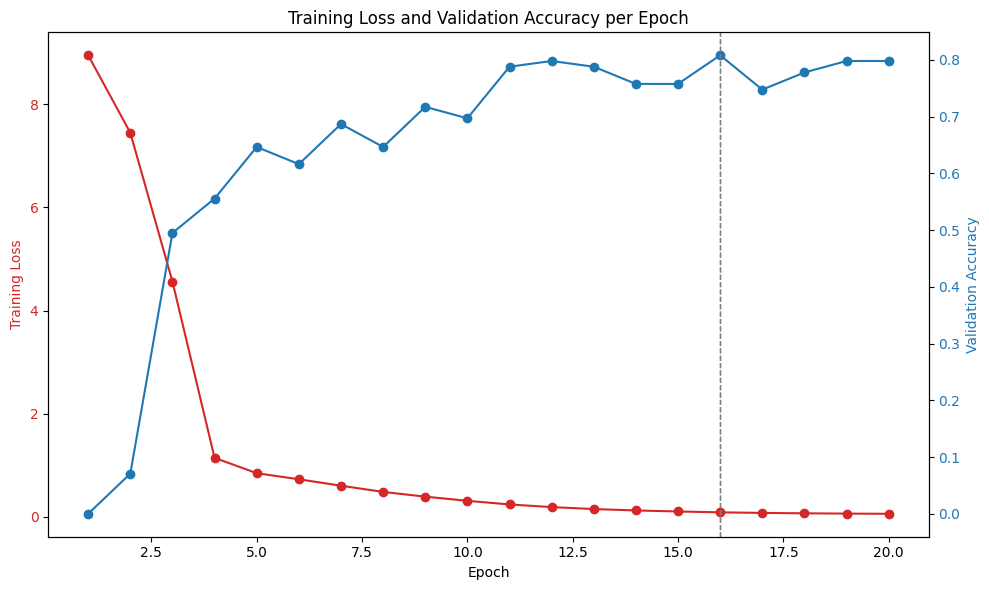

In [20]:
# Extract the data from training_stats.
epochs = [entry['epoch'] for entry in training_stats]
train_loss = [entry['Training Loss'] for entry in training_stats]
valid_acc = [entry['Valid. Acc'] for entry in training_stats]

# Optional: Determine the best epoch based on validation accuracy.
best_epoch = epochs[valid_acc.index(max(valid_acc))]
print("Best Epoch:", best_epoch)

# Create a plot with two y-axes: one for Training Loss and one for Validation Accuracy.
fig, ax1 = plt.subplots(figsize=(10,6))

# Plot the Training Loss on the primary y-axis.
color = 'tab:red'
ax1.set_xlabel('Epoch')
ax1.set_ylabel('Training Loss', color=color)
ax1.plot(epochs, train_loss, color=color, marker='o', label='Training Loss')
ax1.tick_params(axis='y', labelcolor=color)

# Create a second y-axis for Validation Accuracy.
ax2 = ax1.twinx()
color = 'tab:blue'
ax2.set_ylabel('Validation Accuracy', color=color)
ax2.plot(epochs, valid_acc, color=color, marker='o', label='Validation Accuracy')
ax2.tick_params(axis='y', labelcolor=color)

# Add title and a legend.
plt.title('Training Loss and Validation Accuracy per Epoch')
fig.tight_layout()  # Ensure the layout fits the figure area

# Optionally, mark the best epoch on the plot with a vertical line
ax1.axvline(x=best_epoch, color='gray', linestyle='--', linewidth=1)
ax2.axvline(x=best_epoch, color='gray', linestyle='--', linewidth=1)

plt.show()